<a href="https://colab.research.google.com/github/Sneha-code01/ML/blob/main/batterypredict_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# current inida = 0.71, renewable = 0.05, 2035 = 0.35 _CAE
# manufacture = 65kwh electricity required and used 20 for 100%recycle credit
import pandas as pd
from itertools import product

chemistries = [
    'LFP','LTO','LMO','LCO','NCA',
    'NMC111','NMC532','NMC622',
    'NMC811','NMC442','NMC95'
]

scenarios = [
    'Current_India_Grid',
    'Renewable_India',
    'India_2035'
]

recycling_rates = [0,20,30,40,50,60,70,80,90,100]

energy_density = {
    'LFP':140,
    'LTO':80,
    'LMO':150,
    'LCO':190,
    'NCA':260,
    'NMC111':230,
    'NMC532':220,
    'NMC622':250,
    'NMC811':280,
    'NMC442':210,
    'NMC95':300
}

material_emission = {
    'LFP':30,
    'LTO':33,
    'LMO':34,
    'LCO':48,
    'NCA':52,
    'NMC111':43,
    'NMC442':45,
    'NMC532':47,
    'NMC622':50,
    'NMC811':54,
    'NMC95':56
}

cell_production = {
    'LFP':13,
    'LTO':14,
    'LMO':14,
    'LCO':15,
    'NCA':17,
    'NMC111':15,
    'NMC442':15,
    'NMC532':16,
    'NMC622':17,
    'NMC811':18,
    'NMC95':19
}

grid_factor = {
    'Current_India_Grid':0.71,
    'Renewable_India':0.05,
    'India_2035':0.35
}

data = list(product(
    chemistries,
    scenarios,
    recycling_rates
))

df = pd.DataFrame(
    data,
    columns=[
        'Chemistry',
        'Scenario',
        'Recycling_Rate'
    ]
)

df['Energy_Density_kWh'] = (
    df['Chemistry']
    .map(energy_density)
)

df['Material_Emission'] = (
    df['Chemistry']
    .map(material_emission)
)

df['Cell_Production_Emission'] = (
    df['Chemistry']
    .map(cell_production)
)

df['Base_Emission'] = (
    df['Material_Emission']
    +
    df['Cell_Production_Emission']
)

df['Grid_Factor'] = (
    df['Scenario']
    .map(grid_factor)
)

# Manufacturing electricity demand
manufacturing_energy = 65

df['Manufacturing_Emission'] = (
    manufacturing_energy
    *
    df['Grid_Factor']
)

# Recycling credit
df['Recycling_Credit'] = (
    20
    *
    df['Recycling_Rate']
    /100
)

# Final target column
df['CO2-eq-GWP100'] = (
    df['Base_Emission']
    +
    df['Manufacturing_Emission']
    -
    df['Recycling_Credit']
)

print(df[['Chemistry','Scenario','Recycling_Rate','Energy_Density_kWh','CO2-eq-GWP100']])

df.to_csv(
    'battery_dataset.csv',
    index=False
)
#Research_papers: Ellingsen et al. (2014) paper,Ciez & Whitacre (2019) paper,Harper et al. (2019) review paper



    Chemistry            Scenario  Recycling_Rate  Energy_Density_kWh  \
0         LFP  Current_India_Grid               0                 140   
1         LFP  Current_India_Grid              20                 140   
2         LFP  Current_India_Grid              30                 140   
3         LFP  Current_India_Grid              40                 140   
4         LFP  Current_India_Grid              50                 140   
..        ...                 ...             ...                 ...   
325     NMC95          India_2035              60                 300   
326     NMC95          India_2035              70                 300   
327     NMC95          India_2035              80                 300   
328     NMC95          India_2035              90                 300   
329     NMC95          India_2035             100                 300   

     CO2-eq-GWP100  
0            89.15  
1            85.15  
2            83.15  
3            81.15  
4            79.15

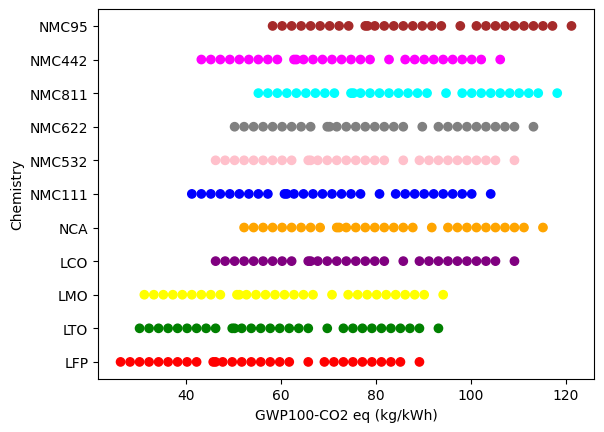

In [12]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',
    'NMC442':'magenta',
    'NMC95':'brown'
}

plt.scatter(
    df['CO2-eq-GWP100'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('GWP100-CO2 eq (kg/kWh)')
plt.ylabel('Chemistry')
plt.show()

In [14]:
# Acidification factors for electricity scenarios
acid_grid_factor = {
    'Current_India_Grid': 0.0035,
    'Renewable_India': 0.0003,
    'India_2035': 0.0015
}

# Base acidification values (kg SO2-eq/kWh battery)
base_acidification = {
    'LFP': 0.20,
    'LTO': 0.22,
    'LMO': 0.23,
    'LCO': 0.31,
    'NCA': 0.34,
    'NMC111': 0.28,
    'NMC442': 0.29,
    'NMC532': 0.30,
    'NMC622': 0.32,
    'NMC811': 0.35,
    'NMC95': 0.37
}

# Add base acidification column
df['Base_Acidification'] = (
    df['Chemistry']
    .map(base_acidification)
)

# Add acidification factor corresponding to electricity scenario
df['Acid_Grid_Factor'] = (
    df['Scenario']
    .map(acid_grid_factor)
)

# Manufacturing acidification contribution
df['Manufacturing_Acidification'] = (
    65 * df['Acid_Grid_Factor']
)

# Recycling credit (maximum 0.10 kg SO2-eq/kWh)
df['Acidification_Credit'] = (
    0.10 * df['Recycling_Rate'] / 100
)

# Final Acidification column
df['Acidification_kg_SO2_eq'] = (
    df['Base_Acidification']
    + df['Manufacturing_Acidification']
    - df['Acidification_Credit']
)

print(
    df[['Chemistry',
        'Scenario',
        'Recycling_Rate',
        'CO2-eq-GWP100',
        'Energy_Density_kWh',
        'Acidification_kg_SO2_eq']]
)

    Chemistry            Scenario  Recycling_Rate  CO2-eq-GWP100  \
0         LFP  Current_India_Grid               0          89.15   
1         LFP  Current_India_Grid              20          85.15   
2         LFP  Current_India_Grid              30          83.15   
3         LFP  Current_India_Grid              40          81.15   
4         LFP  Current_India_Grid              50          79.15   
..        ...                 ...             ...            ...   
325     NMC95          India_2035              60          85.75   
326     NMC95          India_2035              70          83.75   
327     NMC95          India_2035              80          81.75   
328     NMC95          India_2035              90          79.75   
329     NMC95          India_2035             100          77.75   

     Acidification_kg_SO2_eq  
0                     0.4275  
1                     0.4075  
2                     0.3975  
3                     0.3875  
4                     0.3775

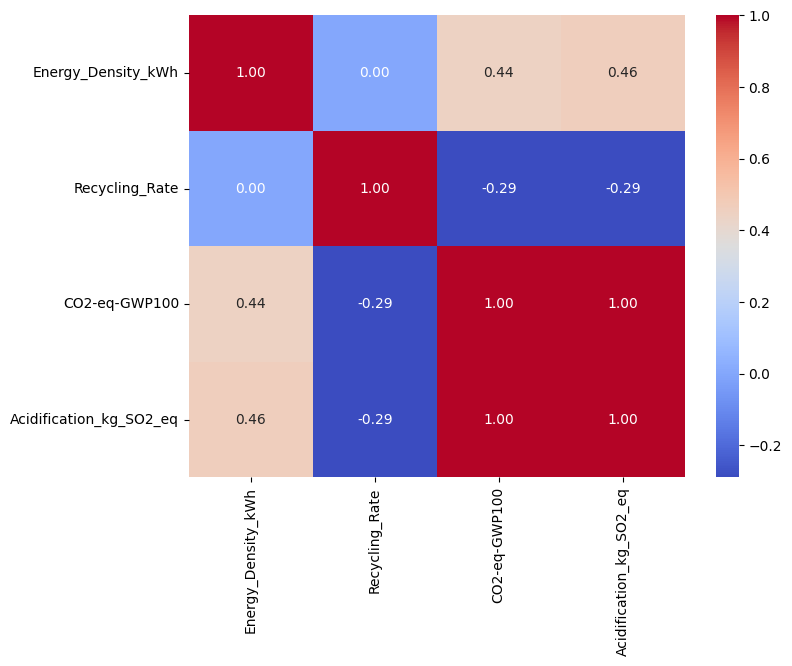

In [18]:
import seaborn as sns
cols = [
    'Energy_Density_kWh',
    'Recycling_Rate',
    'CO2-eq-GWP100',
    'Acidification_kg_SO2_eq'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.show()